In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

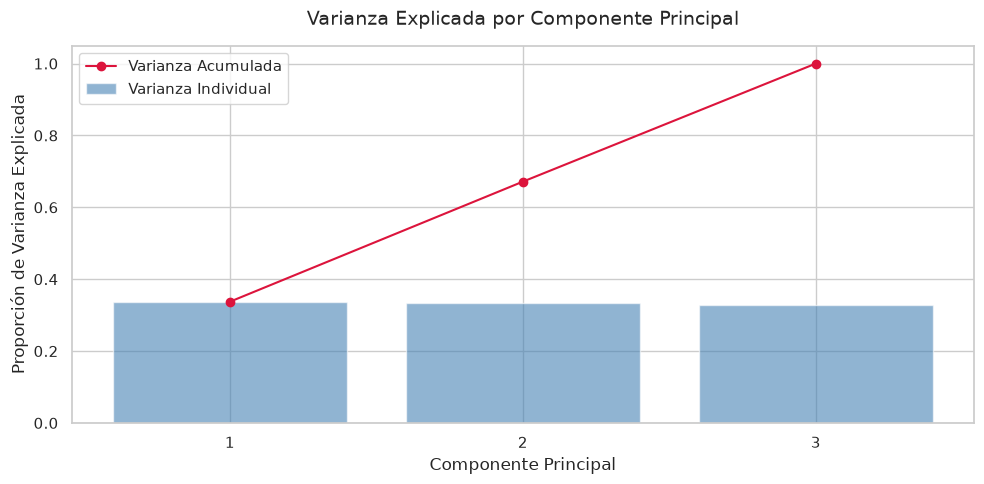

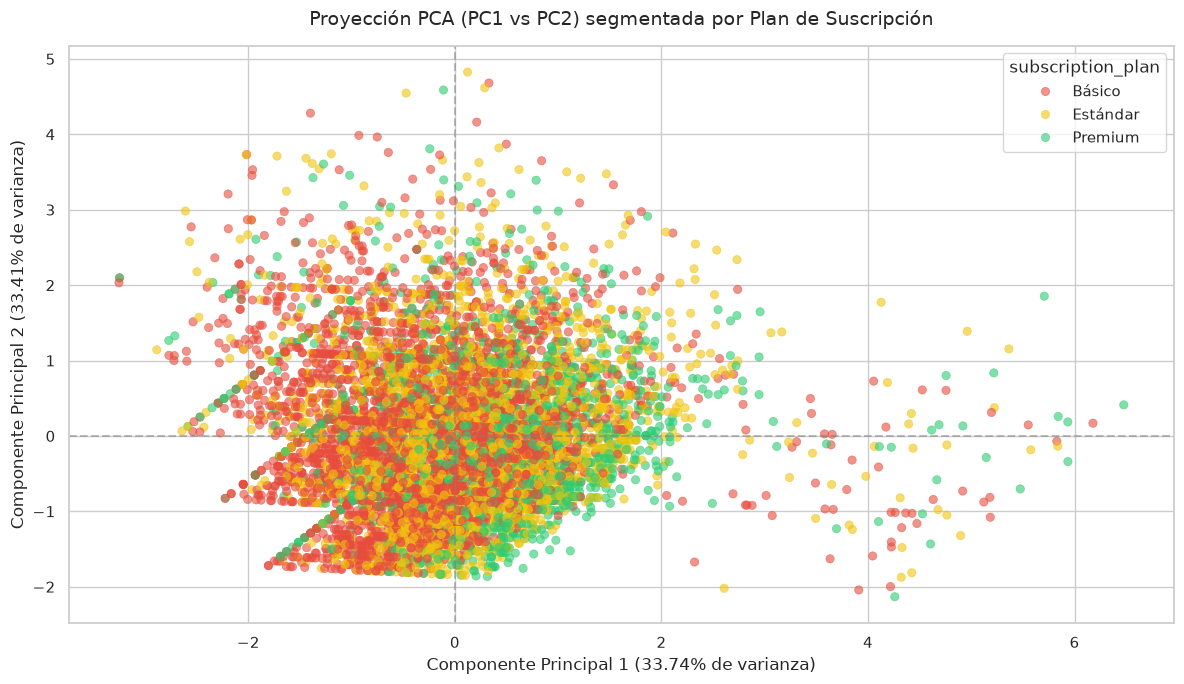

In [2]:
# Configuración estética
sns.set_theme(style="whitegrid")

# 1. Carga del dataset procesado
df = pd.read_csv('../data/processed/streaming_users_clean.csv')

# 2. Selección de las variables numéricas
columnas_num = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
X = df[columnas_num]

# 3. Estandarización de los datos (Obligatorio para PCA)
# Esto centra la media en 0 y la desviación estándar en 1 para todas las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Entrenamiento del modelo PCA
pca = PCA()
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

# 5. Cálculo de la Varianza Explicada
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# 6. GRÁFICO 1: Gráfico de Sedimentación (Scree Plot)
# Muestra cuánta información del dataset original captura cada componente
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, color='steelblue', label='Varianza Individual')
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', color='crimson', label='Varianza Acumulada')
plt.title('Varianza Explicada por Componente Principal', fontsize=14, pad=15)
plt.xlabel('Componente Principal')
plt.ylabel('Proporción de Varianza Explicada')
plt.xticks([1, 2, 3])
plt.legend()
plt.tight_layout()
plt.show()

# 7. GRÁFICO 2: Proyección de Componentes 1 y 2
# Agregamos los componentes principales al dataframe temporalmente para visualizarlos
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# Reutilizamos el orden y los colores de semáforo del EDA
orden_planes = ['Básico', 'Estándar', 'Premium']
colores_semaforo = ['#e74c3c', '#f1c40f', '#2ecc71']

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df, x='PC1', y='PC2', 
    hue='subscription_plan', hue_order=orden_planes, palette=colores_semaforo, 
    alpha=0.6, edgecolor=None
)
plt.title('Proyección PCA (PC1 vs PC2) segmentada por Plan de Suscripción', fontsize=14, pad=15)
plt.xlabel(f'Componente Principal 1 ({varianza_explicada[0]*100:.2f}% de varianza)')
plt.ylabel(f'Componente Principal 2 ({varianza_explicada[1]*100:.2f}% de varianza)')
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Documentación de Variables y Justificación del Escalamiento

El Análisis de Componentes Principales (PCA) se aplicó sobre tres variables numéricas clave de comportamiento e historial del usuario:
1. **Edad (`age`):** Rango de 18 a 80 años (Desviación Estándar = ~9.68).
2. **Tiempo de Visualización Mensual (`monthly_watch_time_mins`):** Rango de 0 a 4,193.7 minutos (Desviación Estándar = ~507.85).
3. **Tickets de Soporte (`customer_support_tickets`):** Rango de 0 a 5 tickets (Desviación Estándar = ~0.90).

#### Justificación del Escalamiento (StandardScaler)
Las tres variables de entrada presentan escalas físicas y varianzas originales abismalmente diferentes. El tiempo de visualización mensual se expresa en miles de minutos, mientras que la edad se mide en decenas de años y los tickets de soporte en unidades unitarias muy pequeñas (0 a 5). 

Si ejecutáramos el algoritmo de PCA directamente sobre los datos crudos, la variable con mayor varianza matemática absoluta (el tiempo de visualización, con un $\sigma^2 pprox 257,914$) dominaría por completo el cálculo de la matriz de covarianza. Como consecuencia, el primer componente principal se alinearía casi en un 100% con esta variable, relegando a las otras dos a un papel insignificante (ruido numérico). 

La aplicación de `StandardScaler` es **obligatoria** en este escenario. Este método resta la media y divide por la desviación estándar a cada variable, transformándolas para que tengan una **media de 0 y una varianza unitaria de 1**. De este modo, se elimina la influencia de las unidades de medida y se garantiza que cada una de las tres variables tenga la misma oportunidad de contribuir a la variabilidad capturada por los componentes principales.

### Análisis de la Varianza Explicada (Scree Plot)

El gráfico de sedimentación (*Scree Plot*) muestra que la varianza explicada por cada componente principal se distribuye de la siguiente manera:
* **Componente Principal 1 (PC1):** Explica el **33.74%** de la varianza total.
* **Componente Principal 2 (PC2):** Explica el **33.41%** de la varianza total.
* **Componente Principal 3 (PC3):** Explica el **32.85%** de la varianza total.
* **Varianza Acumulada (PC1 + PC2):** Representa el **67.15%** de la variabilidad del dataset.

#### Evaluación de la Efectividad de la Reducción Dimensional
A partir de estos resultados, se concluye que **la reducción dimensional mediante PCA en este dataset NO es efectiva**. 

Un proceso de reducción dimensional es exitoso cuando un número reducido de componentes principales (por ejemplo, 1 o 2 componentes de un espacio mayor) logra capturar la gran mayoría de la variabilidad original (típicamente $>80\%$), demostrando que existen variables correlacionadas y redundantes que pueden ser resumidas. 

En este caso, la varianza se distribuye de manera casi equitativa en tres partes iguales (~33% cada una). Esto ocurre porque, como se demostró en el EDA, la correlación lineal entre las variables de entrada es prácticamente nula ($r pprox 0$). Cuando las variables son independientes, el espacio multidimensional es esférico y no elíptico, impidiendo que el PCA encuentre direcciones preferenciales de varianza. Reducir las dimensiones a 2 componentes principales (PC1 y PC2) implica **perder un 32.85% de la información original**, lo cual equivale casi exactamente a descartar una de las tres variables por completo (1 de 3 variables representa el 33.3% del total). Por ende, el PCA no aporta una simplificación informativa eficiente en este caso.

### Interpretación de la Proyección PCA y Agrupación por Plan

Para comprender la estructura de los datos proyectados en el plano bidimensional definido por PC1 (eje X) y PC2 (eje Y), analizamos los pesos (*loadings*) que definen a cada componente:
* **PC1 (33.74% de varianza):** Presenta un peso positivo fuerte en `monthly_watch_time_mins` (**0.735**) y en `age` (**0.564**), combinado con un peso negativo moderado en `customer_support_tickets` (**-0.375**). Define a usuarios con **alto volumen de consumo, mayor edad y baja fricción operativa** (pocas reclamaciones).
* **PC2 (33.41% de varianza):** Presenta un peso positivo fuerte en `customer_support_tickets` (**0.800**) y en `age` (**0.597**), con una influencia casi nula del consumo mensual (**-0.050**). Define a usuarios de **mayor edad y alta fricción con soporte**, independientemente de lo mucho o poco que consuman en la plataforma.

#### Comportamiento y Agrupamiento según el Plan de Suscripción
Al proyectar a los usuarios y segmentarlos por su plan de suscripción en el gráfico de dispersión, se desprenden las siguientes conclusiones analíticas:

1. **Desplazamiento de los Centroides (Medias):**
   * **Plan Básico:** Tiene su centroide promedio en las coordenadas de PC1 = **-0.261**, PC2 = **0.018**. Tiende a posicionarse más hacia la izquierda en el eje PC1, lo cual está alineado con su menor promedio de consumo mensual de minutos (~592 mins).
   * **Plan Estándar:** Tiene su centroide promedio en PC1 = **0.135**, PC2 = **-0.008**. Ocupa una posición intermedia cercana al origen de coordenadas.
   * **Plan Premium:** Tiene su centroide promedio en PC1 = **0.355**, PC2 = **-0.027**. Se desplaza ligeramente hacia la derecha en el eje PC1, impulsado por el alto consumo promedio de minutos mensual (~1,020 mins).

2. **Solapamiento Visual y Diagnóstico Comercial:**
   A pesar de las sutiles diferencias en los promedios de PC1 descritos anteriormente, **las nubes de puntos de los tres planes de suscripción se superponen (solapan) de manera casi total en la proyección**. Los rangos de dispersión (min/max) de PC1 y PC2 son prácticamente idénticos para el plan Básico, Estándar y Premium (todos cubren de -3.2 a 6.4 en PC1 y de -2.1 a 4.8 en PC2). No existe una separación visual ni formación de agrupaciones (*clusters*) independientes.

   **Conclusión de Negocio:** La segmentación actual basada exclusivamente en la jerarquía del plan contratado (Básico, Estándar o Premium) es **insuficiente** para definir perfiles demográficos o conductuales diferenciados de soporte y consumo. Un gran número de clientes del plan Básico comparte el mismo espacio de consumo y comportamiento que los clientes Premium. Para campañas efectivas de retención o personalización de contenido, el negocio no debe basarse en el tipo de plan, sino que requiere la implementación de almenos algoritmos de agrupamiento no supervisado (como K-Means) que aglutinen a los usuarios según sus hábitos reales de consumo y patrones de interacción técnica.